# Monobank Finance X-Ray: Machine Learning & Predictive Analytics

This notebook is dedicated to applying Machine Learning algorithms (Unsupervised Learning and Time Series Analysis) to our financial history.

**Objectives:**
1. **Intelligent Clustering (K-Means):** Discover hidden behavioral patterns in daily expenses.
2. **Subscription Detection:** Automatically identify regular recurring payments across thousands of transactions.# Monobank Finance X-Ray: Machine Learning & Predictive Analytics

This notebook is dedicated to applying Machine Learning algorithms (Unsupervised Learning and Time Series Analysis) to our financial history.

**Objectives:**
1. **Intelligent Clustering (K-Means):** Discover hidden behavioral patterns in daily expenses.
2. **Subscription Detection:** Automatically identify regular recurring payments across thousands of transactions.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sys.path.append(os.path.abspath('..'))
from src.database import engine

load_dotenv('../.env')

query = "SELECT * FROM transactions WHERE amount < 0 ORDER BY time"
df = pd.read_sql(query, engine)

df['amount'] = df['amount'].abs()

print(f"Loaded {len(df)} expense transactions for Machine Learning!")

Loaded 2897 expense transactions for Machine Learning!


## 1. Feature Engineering & K-Means Clustering

The **K-Means** algorithm groups data into clusters so that data points within the same cluster are as similar as possible.

To help the model understand the context of our purchases, we extract new features from the transaction timestamp:
* `hour`: The hour of the day.
* `day_of_week`: The day of the week.
* `amount`: The transaction amount.

In [2]:
df_ml = df[['time', 'amount', 'description', 'category']].copy()
df_ml['hour'] = df_ml['time'].dt.hour
df_ml['day_of_week'] = df_ml['time'].dt.dayofweek

features = df_ml[['amount', 'hour', 'day_of_week']]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

## Finding the Optimal K (Elbow Method)

Before interpreting the clusters, let's mathematically prove the optimal number of groups using the Elbow Method. We calculate the Within-Cluster Sum of Squares (WCSS) for 1 to 10 clusters to find the point of diminishing returns.

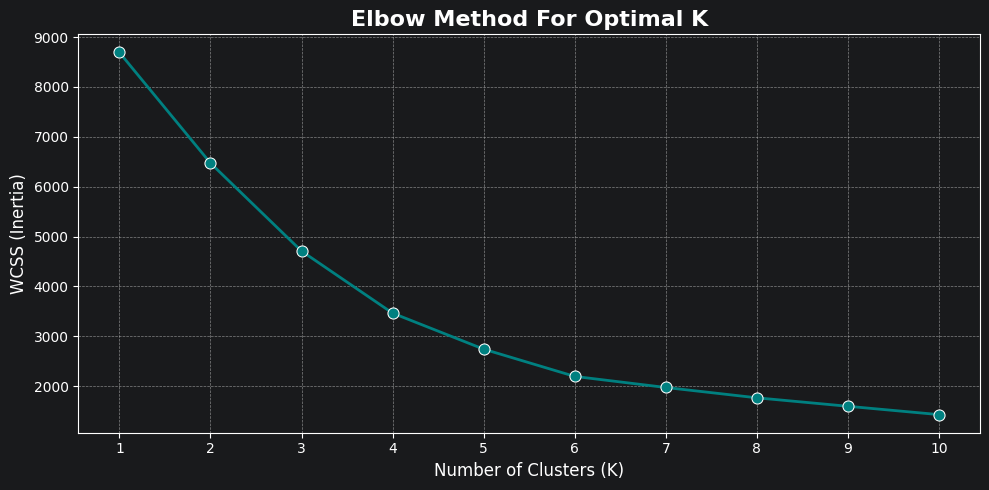

In [3]:
wcss = []
k_range = range(1, 11)

for i in k_range:
    kmeans_test = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans_test.fit(features_scaled)
    wcss.append(kmeans_test.inertia_)

plt.figure(figsize=(10, 5))
sns.lineplot(x=list(k_range), y=wcss, marker='o', color='teal', linewidth=2, markersize=8)
plt.title('Elbow Method For Optimal K', fontsize=16, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Elbow Method shown us that 4 clusters is optimal amount

In [4]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_ml['cluster'] = kmeans.fit_predict(features_scaled)

print("K-Means model successfully trained and assigned 4 clusters!")
display(df_ml[['time', 'amount', 'description', 'cluster']].head(10))

K-Means model successfully trained and assigned 4 clusters!


,time,amount,description,cluster
0,2021-10-25 14:21:37,18.40,АТБ №792,2
1,2021-10-25 17:07:58,14.49,Сільпо,2
2,2021-10-25 17:31:28,34.50,АТБ,2
3,2021-10-25 18:06:53,17.00,MagazinProdukti,2
4,2021-10-26 11:59:13,30.20,АТБ №792,1
5,2021-10-27 12:19:33,122.00,McDonald’s,1
6,2021-10-28 16:14:31,11.30,АТБ,2
7,2021-10-28 17:35:10,30.20,АТБ,2
8,2021-10-28 18:04:05,9.90,OPT 243 PAVIC,2
9,2021-11-05 18:31:08,402.00,Банкомат IVANA MAZEPY. 37,0


## 2. Cluster Profiling: Understanding the Patterns

To interpret what each cluster represents, we will calculate the average transaction amount, the average time of day, and the most frequent day of the week for each group. This allows us to assign a logical "persona" to each cluster.

In [5]:
cluster_summary = df_ml.groupby('cluster').agg(
    Transaction_Count=('amount', 'count'),
    Average_Amount_UAH=('amount', 'mean'),
    Average_Hour=('hour', 'mean'),
    Average_Day=('day_of_week', 'mean')
).round(2)

top_categories = df_ml.groupby('cluster')['category'].agg(lambda x: x.mode()[0])
cluster_summary['Top_Category'] = top_categories

print("Cluster Profiles:")
display(cluster_summary)

Cluster Profiles:


,Transaction_Count,Average_Amount_UAH,Average_Hour,Average_Day,Top_Category
cluster,,,,,
0,907,100.69,15.54,5.17,Markets / Specialty Foods
1,922,131.20,9.39,3.08,Markets / Specialty Foods
2,1032,119.33,15.84,1.39,Markets / Specialty Foods
3,36,5219.63,14.06,2.67,Money Transfers


## 3. 3D Visualization of Financial Habits

To better understand the boundaries between our identified behaviors, we can visualize the K-Means clusters in a 3-dimensional space. By mapping our features to the X, Y, and Z axes, we can visually inspect how the algorithm separated the data points.

* **X-axis (Hour of Day):** Differentiates morning routines from evening activities.
* **Y-axis (Day of Week):** Separates weekday expenditures from weekend shopping.
* **Z-axis (Amount):** Isolates standard daily purchases from rare, high-value transfers.

This spatial representation provides a clear visual confirmation of the cluster profiles we defined above.

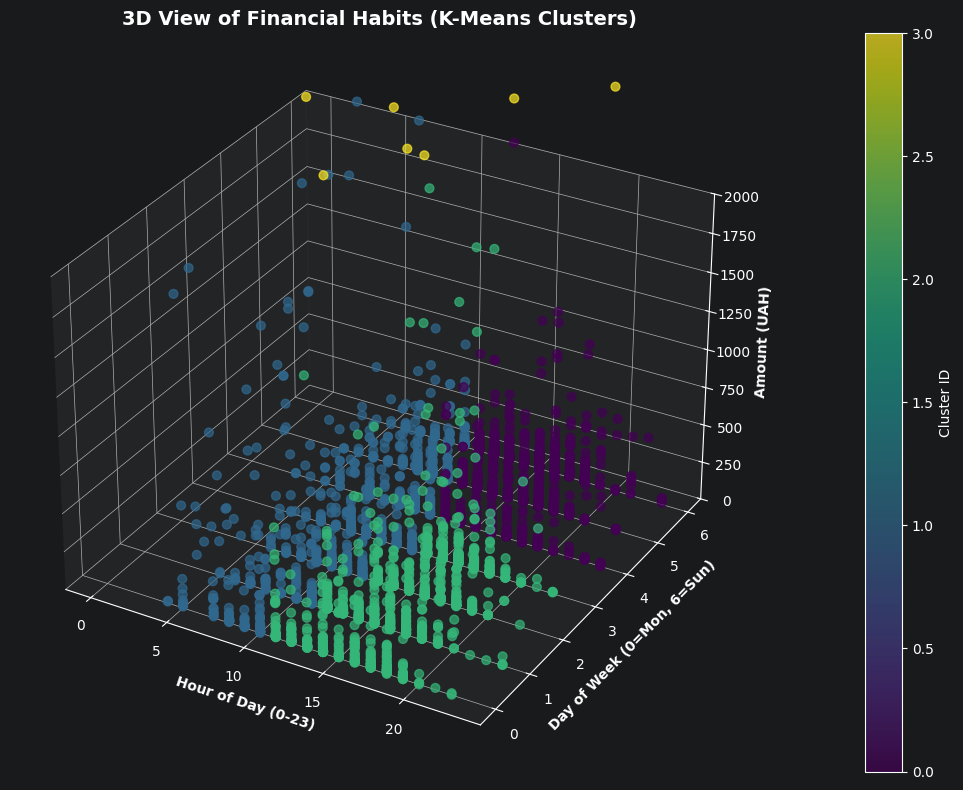

In [6]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_ml['hour'],
    df_ml['day_of_week'],
    df_ml['amount'],
    c=df_ml['cluster'],
    cmap='viridis',
    s=40,
    alpha=0.7
)

ax.set_xlabel('Hour of Day (0-23)', fontweight='bold')
ax.set_ylabel('Day of Week (0=Mon, 6=Sun)', fontweight='bold')
ax.set_zlabel('Amount (UAH)', fontweight='bold')
ax.set_title('3D View of Financial Habits (K-Means Clusters)', fontsize=14, fontweight='bold')

ax.set_zlim(0, 2000)

cbar = plt.colorbar(scatter, pad=0.1)
cbar.set_label('Cluster ID')

plt.tight_layout()
plt.show()

## 4. Time Series Analysis: Behavioral Routine & Habit Detection

While standard recurring payments (like digital subscriptions) are common, identifying predictable behavioral routines provides deeper insight into daily lifestyle.

Here, we build an algorithm that:
1. **Standardizes merchant names** to resolve data entry inconsistencies (e.g., casing issues).
2. **Groups transactions** by merchant and calculates the time gap (in days) between consecutive visits.
3. **Identifies "Consumer Hubs"** by evaluating transaction volume and the stability of the cadence (Interval Volatility) to uncover regular lifestyle habits.

In [15]:
df_ml['clean_description'] = df_ml['description'].str.strip().str.lower().str.capitalize()

merchant_counts = df_ml['clean_description'].value_counts()
frequent_merchants = merchant_counts[merchant_counts >= 5].index
frequent_tx = df_ml[df_ml['clean_description'].isin(frequent_merchants)].copy()

frequent_tx = frequent_tx.sort_values(by=['clean_description', 'time'])

frequent_tx['days_since_last'] = frequent_tx.groupby('clean_description')['time'].diff().dt.days

routine_stats = frequent_tx.groupby('clean_description').agg(
    Tx_Count=('amount', 'count'),
    Avg_Amount_UAH=('amount', 'mean'),
    Median_Interval_Days=('days_since_last', 'median'),
    Interval_Volatility=('days_since_last', 'std')
).dropna()

print("Consumer Hubs & Behavioral Routines Analysis:")
display(routine_stats.sort_values(by='Tx_Count', ascending=False).head(10).round(2))

Consumer Hubs & Behavioral Routines Analysis:


,Tx_Count,Avg_Amount_UAH,Median_Interval_Days,Interval_Volatility
clean_description,,,,
Атб,275,47.84,2.0,10.49
Київське метро,249,8.00,0.0,16.13
Маркетопт,218,73.03,1.0,18.79
Фора,204,99.48,1.0,10.20
Ipay.ua,199,10.12,0.0,16.18
Переказ на картку,93,297.12,0.0,9.20
Сільпо,77,83.52,5.0,41.66
Mcdonald’s,67,202.04,10.0,76.28
Кицюня❤️,63,241.77,6.0,10.03


## 5. Predictive Analytics: Financial Runway (Burn Rate)

In startups and personal finance, "Burn Rate" is the speed at which money is spent. By calculating our average daily spending over the most recent 30 days, we can project a "Financial Runway" - an estimation of how many days our current balance will last before hitting zero, assuming our spending habits remain unchanged.

Real balance successfully loaded: 161.63 UAH

Average Daily Burn Rate: 609.71 UAH / day
Financial Runway: 0 days
Projected Zero Balance Date: 2026-06-03


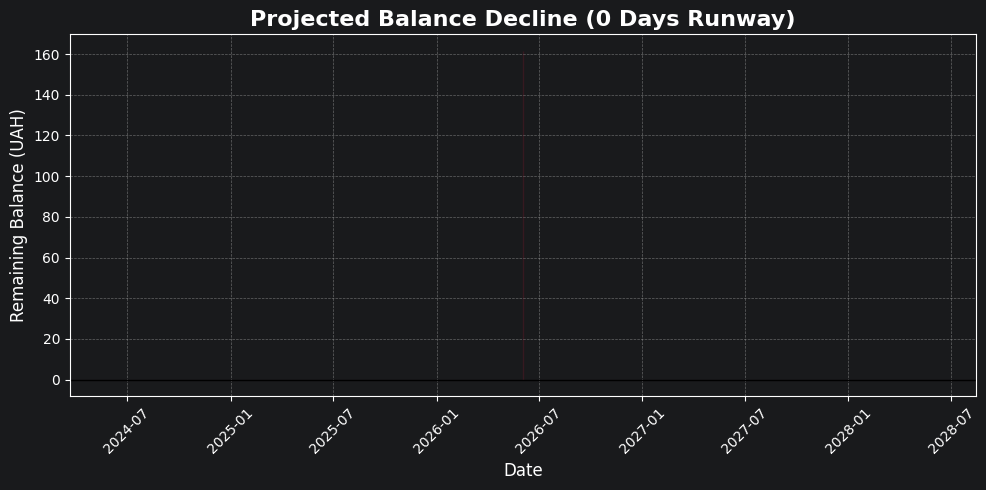

In [24]:
import os
import requests
import datetime
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

try:
    mono_token = os.environ.get('MONOBANK_API_TOKEN')
    target_account_id = os.environ.get('MONOBANK_ACCOUNT_ID')

    if not mono_token:
        raise ValueError("Токен не знайдено!")

    headers = {'X-Token': mono_token}
    response = requests.get('https://api.monobank.ua/personal/client-info', headers=headers)
    response.raise_for_status()
    client_info = response.json()

    real_balance = None

    if target_account_id:
        for account in client_info['accounts']:
            if account['id'] == target_account_id:
                real_balance = account['balance'] / 100.0
                break

    if real_balance is None:
        raise ValueError(f"Рахунок з ID {target_account_id} не знайдено серед твоїх карток!")

    CURRENT_BALANCE = real_balance
    print(f"Real balance successfully loaded: {CURRENT_BALANCE} UAH")

except Exception as e:
    print(f"⚠Error fetching real balance from API: {e}")
    print("Switching to fallback test balance.")
    CURRENT_BALANCE = 10000.0

last_date = df_ml['time'].max()
start_date = last_date - pd.Timedelta(days=30)
recent_df = df_ml[df_ml['time'] >= start_date]

daily_spend = recent_df.groupby(recent_df['time'].dt.date)['amount'].sum()
avg_daily_burn = daily_spend.mean()

if avg_daily_burn > 0:
    runway_days = int(CURRENT_BALANCE / avg_daily_burn)
    zero_cash_date = last_date + pd.Timedelta(days=runway_days)

    print(f"\nAverage Daily Burn Rate: {avg_daily_burn:.2f} UAH / day")
    print(f"Financial Runway: {runway_days} days")
    print(f"Projected Zero Balance Date: {zero_cash_date.date()}")

    future_dates = [last_date.date() + datetime.timedelta(days=i) for i in range(runway_days + 1)]
    projected_balances = [CURRENT_BALANCE - (avg_daily_burn * i) for i in range(runway_days + 1)]

    plt.figure(figsize=(10, 5))
    plt.plot(future_dates, projected_balances, color='crimson', linewidth=2, linestyle='-')
    plt.fill_between(future_dates, projected_balances, 0, color='crimson', alpha=0.15)

    plt.title(f"Projected Balance Decline ({runway_days} Days Runway)", fontsize=16, fontweight='bold')
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Remaining Balance (UAH)", fontsize=12)
    plt.axhline(0, color='black', linewidth=1)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough recent expenses to calculate a valid burn rate.")